# End-to-End Sales Forecasting & Demand Intelligence System

### Prepared By
**Name:** Anju Kumari

---

## Objective

The objective of this project is to build an intelligent sales forecasting system capable of predicting future product demand, detecting unusual sales patterns, segmenting products based on demand behavior, and presenting business insights through an interactive dashboard.

The project covers:

- Data Cleaning
- Exploratory Data Analysis
- Time Series Analysis
- Sales Forecasting
- Machine Learning
- Anomaly Detection
- Product Demand Segmentation
- Streamlit Dashboard Deployment

# Problem Statement

Retail companies face a major challenge:

**How much inventory should be stocked in the coming months?**

Poor demand forecasting can lead to:

- Overstocking
- Understocking
- Increased warehouse costs
- Lost customers
- Reduced revenue

This project aims to solve this problem by analysing historical sales data, forecasting future demand using multiple forecasting techniques, identifying unusual sales patterns, and generating actionable business insights.

In [2]:
# Reading the dataset

import pandas as pd

df = pd.read_csv("train.csv")

print("Dataset Loaded Successfully ✅")

Dataset Loaded Successfully ✅


In [3]:
import pandas as pd

## Step 2: Load the Dataset

Now we will load the Superstore Sales dataset into a Pandas DataFrame.

In [4]:
# Read the CSV file

df = pd.read_csv("train.csv")

In [5]:
# Display first five rows

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Step 3: Understanding the Dataset

Before cleaning or analyzing the dataset, it is important to understand its structure.

In this section, we will inspect:

- Number of rows and columns
- Column names
- Data types
- Sample records
- General information about the dataset

In [6]:
# Shape of Dataset

df.shape

(9800, 18)

### Observation

The dataset contains **9,800 records** and **18 features**. This indicates that sufficient historical sales data is available for performing exploratory data analysis, feature engineering, and building reliable forecasting models.

Knowing the dataset size at the beginning helps estimate computational requirements and provides an overview of the available information for further analysis.

In [7]:
# Display all column names

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

### Observation

The dataset contains customer, product, order, shipping, and sales-related features. The **Order Date** column will be the primary time variable for forecasting, while **Sales** will be the target variable.

In [8]:
# Get dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [9]:
# Count unique values in each column

df.nunique().sort_values(ascending=False)

,0
Row ID,9800
Sales,5757
Order ID,4922
Product ID,1861
Product Name,1849
Ship Date,1326
Order Date,1230
Customer ID,793
Customer Name,793
Postal Code,626


### Observation

The dataset contains **9,800 records** and **18 columns**. Most columns have complete data, while the **Postal Code** column contains **11 missing values**. Additionally, **Order Date** and **Ship Date** are currently stored as object data types and need to be converted to datetime format before performing time series analysis.

In [10]:
# Check missing values

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [11]:
missing = df.isnull().sum()

missing_percentage = (
    missing / len(df) * 100
).round(2)

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

,Missing Values,Percentage
Row ID,0,0.00
Order ID,0,0.00
Order Date,0,0.00
Ship Date,0,0.00
Ship Mode,0,0.00
Customer ID,0,0.00
Customer Name,0,0.00
Segment,0,0.00
Country,0,0.00
City,0,0.00


### Observation

The dataset has very few missing values. Only the **Postal Code** column contains missing values (11 records), while all other columns are complete. Since Postal Code is not essential for sales forecasting, we can safely handle these missing values during preprocessing.

In [12]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

### Observation

The dataset contains **no duplicate records**, indicating that each row represents a unique sales transaction. Therefore, no duplicate removal is required.

In [13]:
# Convert date columns into datetime format

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

print("Date conversion completed successfully.")

Date conversion completed successfully.


In [14]:
# Verify the updated data types

df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


### Observation

The **Order Date** and **Ship Date** columns were successfully converted from object type to datetime format. This conversion is essential because time-series forecasting requires date values to perform operations such as extracting year, month, week, and trend analysis.

# Step 4: Feature Engineering

Feature engineering involves creating new features from existing data that can improve analysis and forecasting models.

In this step, we will extract useful time-based features from the **Order Date** column.

In [15]:
# Extract time-based features

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df['Quarter'] = df['Order Date'].dt.quarter
df['Week'] = df['Order Date'].dt.isocalendar().week
df['Day'] = df['Order Date'].dt.day
df['Day Name'] = df['Order Date'].dt.day_name()
df["Is_Weekend"] = (
    df["Order Date"].dt.dayofweek >= 5
)

df["Month_Start"] = (
    df["Order Date"].dt.is_month_start
)

df["Month_End"] = (
    df["Order Date"].dt.is_month_end
)

print("Time features created successfully.")

Time features created successfully.


In [16]:
# Display newly created features

df[['Order Date','Year','Month','Month Name','Quarter','Week','Day','Day Name']].head()

,Order Date,Year,Month,Month Name,Quarter,Week,Day,Day Name
0,2017-11-08,2017,11,November,4,45,8,Wednesday
1,2017-11-08,2017,11,November,4,45,8,Wednesday
2,2017-06-12,2017,6,June,2,24,12,Monday
3,2016-10-11,2016,10,October,4,41,11,Tuesday
4,2016-10-11,2016,10,October,4,41,11,Tuesday


### Observation

New time-based features were successfully extracted from the **Order Date** column. These features will help analyze seasonal trends, yearly growth, monthly sales patterns, and will also be used as inputs for forecasting models.

In [17]:
# Create Season column

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

print("Season feature created successfully.")

Season feature created successfully.


In [18]:
# Verify Season column

df[['Order Date', 'Month', 'Season']].head(10)

,Order Date,Month,Season
0,2017-11-08,11,Autumn
1,2017-11-08,11,Autumn
2,2017-06-12,6,Summer
3,2016-10-11,10,Autumn
4,2016-10-11,10,Autumn
5,2015-06-09,6,Summer
6,2015-06-09,6,Summer
7,2015-06-09,6,Summer
8,2015-06-09,6,Summer
9,2015-06-09,6,Summer


### Observation

The **Season** feature was created using the **Month** column. This feature enables seasonal sales analysis and can improve forecasting models by capturing recurring seasonal demand patterns.

In [19]:
# Display first five rows with all new features

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Month,Month Name,Quarter,Week,Day,Day Name,Is_Weekend,Month_Start,Month_End,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,11,November,4,45,8,Wednesday,False,False,False,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,11,November,4,45,8,Wednesday,False,False,False,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,6,June,2,24,12,Monday,False,False,False,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,10,October,4,41,11,Tuesday,False,False,False,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,10,October,4,41,11,Tuesday,False,False,False,Autumn


In [20]:
# Save the cleaned dataset for future use

df.to_csv("sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


## Step 4 Completed

The dataset has been successfully preprocessed by:

- Converting date columns to datetime format
- Creating Year, Month, Month Name, Quarter, Week, Day, Day Name, and Season features
- Saving the cleaned dataset for further analysis

The dataset is now ready for Exploratory Data Analysis (EDA).

# Step 5: Exploratory Data Analysis (EDA)

In this section, we will explore the sales data to identify business insights, trends, and patterns. The analysis will answer key business questions using visualizations and summary statistics.

## Business Question 1

### Which product category generates the highest total revenue?

In [21]:
import matplotlib.pyplot as plt

In [22]:
# Calculate total sales by category

category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)
category_percentage = (
    category_sales /
    category_sales.sum() * 100
).round(2)

display(category_percentage)

display(category_sales)

,Sales
Category,
Technology,36.59
Furniture,32.22
Office Supplies,31.19


,Sales
Category,
Technology,827455.87
Furniture,728658.58
Office Supplies,705422.33


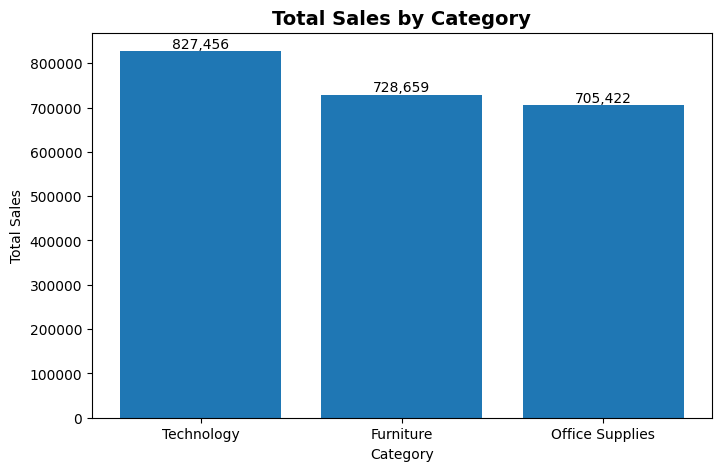

In [23]:
plt.figure(figsize=(8,5))

bars = plt.bar(category_sales.index, category_sales.values)

plt.title("Total Sales by Category", fontsize=14,
          fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.show()

### Observation

The Technology category generated the highest sales, contributing approximately 36.59% of the total revenue, followed by Furniture (32.22%) and Office Supplies (31.19%). This indicates that technology products contribute the largest share of revenue in the Superstore dataset.

## Business Question 2

### Which region generates the highest total sales?

In [24]:
# Total sales by region

region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .round(2)
)
region_percentage = (
    region_sales /
    region_sales.sum() * 100
).round(2)

display(region_percentage)

display(region_sales)

,Sales
Region,
West,31.40
East,29.60
Central,21.78
South,17.21


,Sales
Region,
West,710219.68
East,669518.73
Central,492646.91
South,389151.46


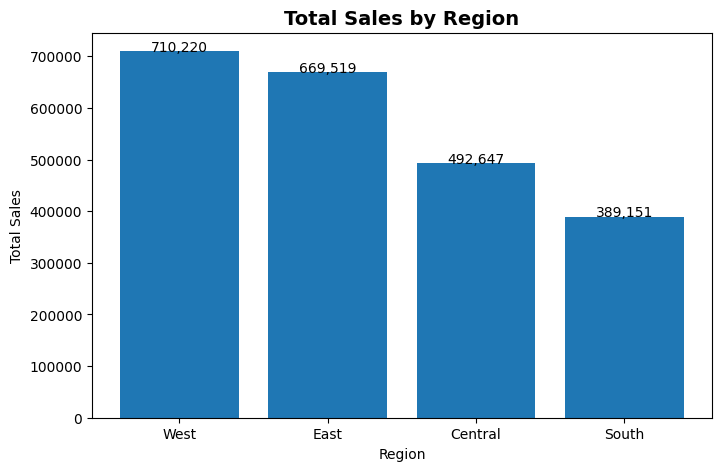

In [25]:
# Plot total sales by region

plt.figure(figsize=(8,5))

bars = plt.bar(region_sales.index, region_sales.values)

plt.title("Total Sales by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")

for bar in bars:
    plt.text(
        bar.get_x()+bar.get_width()/2,
        bar.get_height(),
        f'{bar.get_height():,.0f}',
        ha='center'
    )

plt.show()

### Observation

The West region contributed approximately 31.40%
of total sales, making it the highest-performing region, followed by the East region.

## Business Question 3

### What are the monthly sales trends?

In [26]:
# Monthly sales trend

monthly_sales = (
    df.groupby(["Year","Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_sales

,Year,Month,Sales
0,2015,1,14205.7070
1,2015,2,4519.8920
2,2015,3,55205.7970
3,2015,4,27906.8550
4,2015,5,23644.3030
5,2015,6,34322.9356
6,2015,7,33781.5430
7,2015,8,27117.5365
8,2015,9,81623.5268
9,2015,10,31453.3930


In [27]:
# Create a proper date column for plotting

monthly_sales["Date"] = pd.to_datetime(
    monthly_sales["Year"].astype(str) + "-" +
    monthly_sales["Month"].astype(str)
)
monthly_sales.loc[
    monthly_sales["Sales"].idxmax()
]
monthly_sales.loc[
    monthly_sales["Sales"].idxmin()
]

monthly_sales.head()

,Year,Month,Sales,Date
0,2015,1,14205.707,2015-01-01
1,2015,2,4519.892,2015-02-01
2,2015,3,55205.797,2015-03-01
3,2015,4,27906.855,2015-04-01
4,2015,5,23644.303,2015-05-01


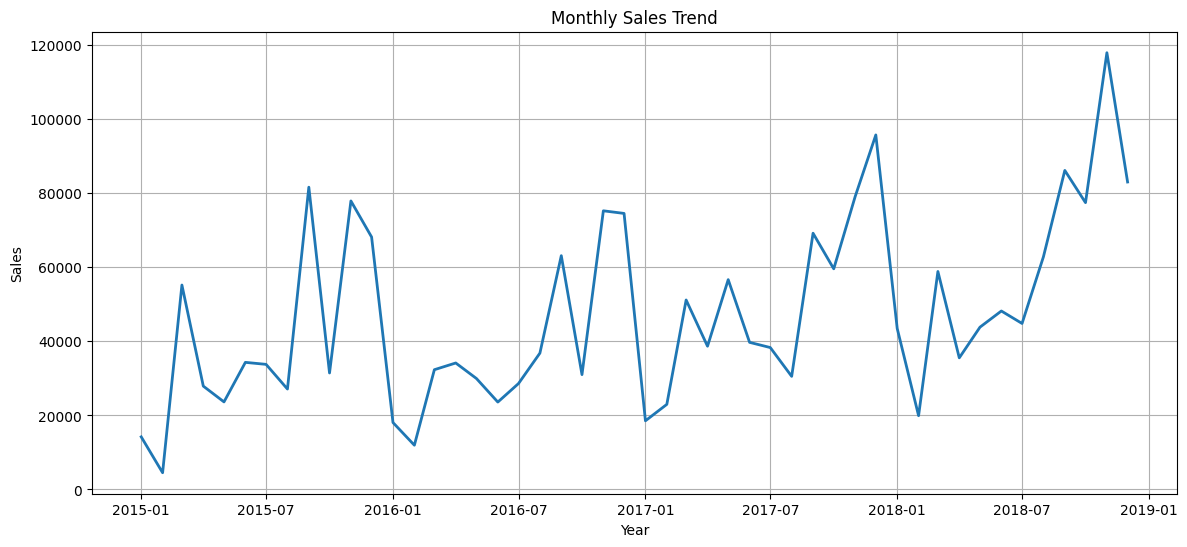

In [28]:
# Monthly Sales Trend

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Date"],
    monthly_sales["Sales"],
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

Monthly sales fluctuate over time with an overall increasing trend. Highest sales occurred in November 2018.Lowest sales occurred in February 2015.

## Business Question 4

### Which Sub-Category generates the highest sales?

In [29]:
# Total Sales by Sub-Category

subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)
top10 = subcategory_sales.head(10)
top10

,Sales
Sub-Category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


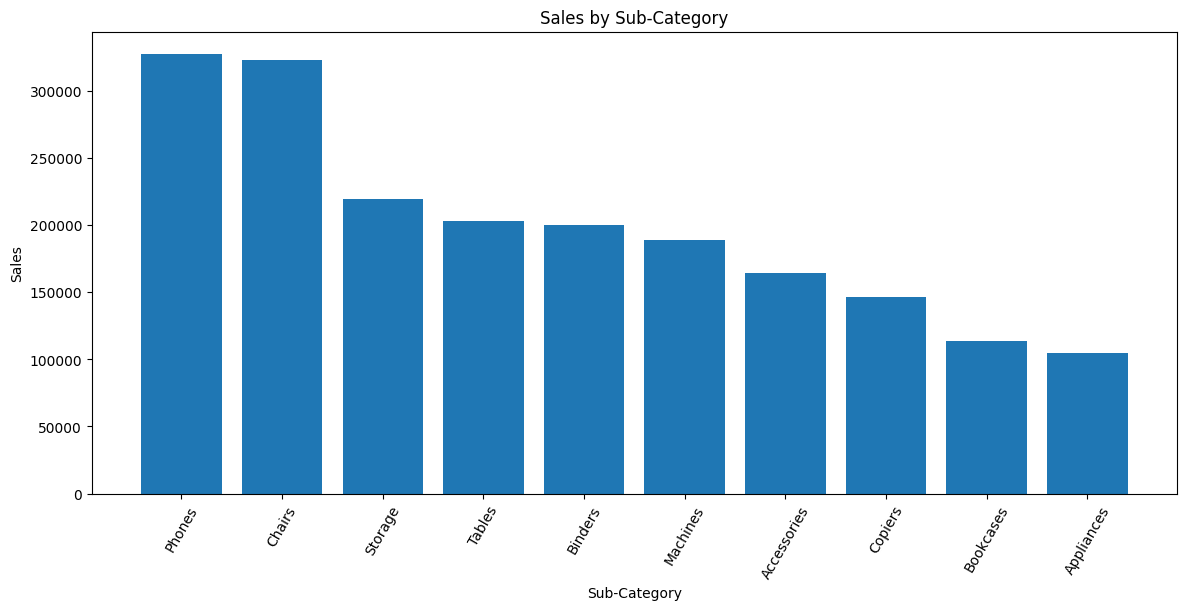

In [30]:
plt.figure(figsize=(14,6))

bars = plt.bar(
    top10.index,
    top10.values
)

plt.title("Sales by Sub-Category")
plt.xlabel("Sub-Category")
plt.ylabel("Sales")

plt.xticks(rotation=60)

plt.show()

### Observation

The sub-category analysis identifies the products contributing the highest revenue. This helps businesses prioritize inventory and demand planning for high-performing products.

## Business Question 5

### Which customer segment contributes the highest sales?

In [31]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


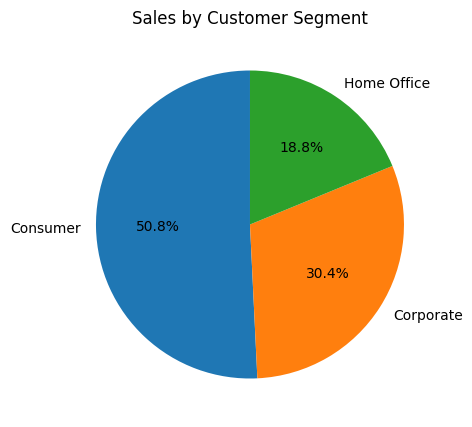

In [32]:
plt.figure(figsize=(7,5))

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Sales by Customer Segment")

plt.show()

### Observation

The Consumer segment contributes the highest share of sales, followed by Corporate and Home Office customers.

## Business Question 6

### What is the average shipping time?

In [33]:
# Shipping Time

df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

df["Shipping Days"].describe()
print(
    "Average Shipping Days:",
    round(df["Shipping Days"].mean(), 2)
)

Average Shipping Days: 3.96


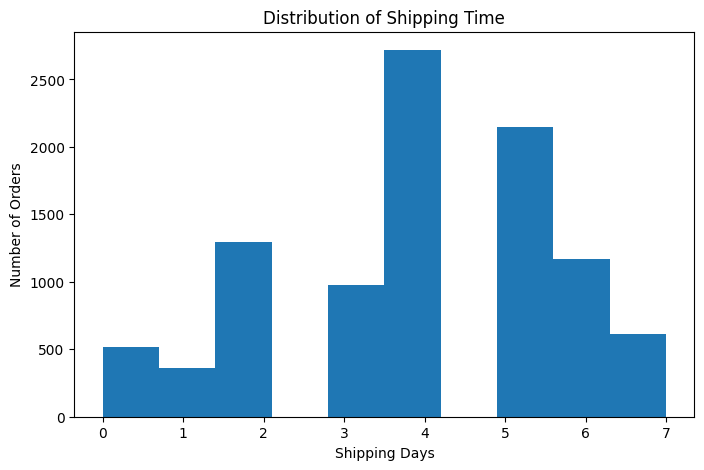

In [34]:
plt.figure(figsize=(8,5))

plt.hist(df["Shipping Days"], bins=10)

plt.title("Distribution of Shipping Time")

plt.xlabel("Shipping Days")
plt.ylabel("Number of Orders")

plt.show()

### Observation

The shipping analysis shows the average number of days taken to deliver customer orders. This metric helps evaluate logistics efficiency and regional delivery performance.

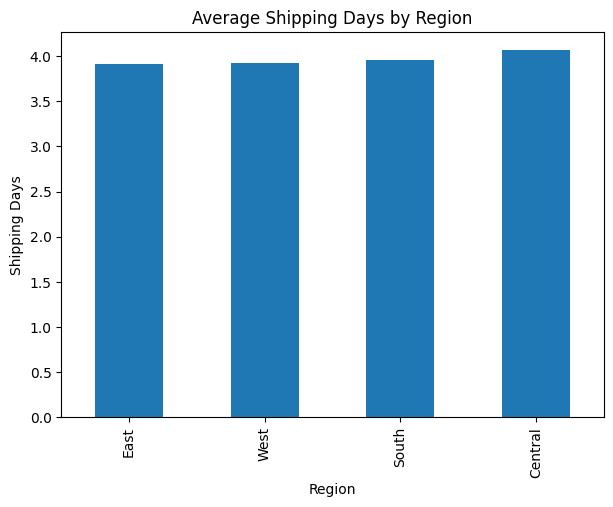

,Shipping Days
Region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


In [35]:
# Average Shipping Time by Region

shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)
plt.figure(figsize=(7,5))

shipping_region.plot(kind="bar")

plt.title("Average Shipping Days by Region")

plt.ylabel("Shipping Days")

plt.show()

shipping_region

### Observation

Comparing shipping time across regions helps identify operational differences and areas where delivery performance can be improved.

# Step 6: Time Series Analysis

Time series analysis helps us understand how sales change over time by identifying trends, seasonality, and random variations before building forecasting models.

In [36]:
# Monthly Sales Time Series

monthly_ts = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .resample("M")
      .sum()
)

monthly_ts.head()

/tmp/ipykernel_653/2777389261.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


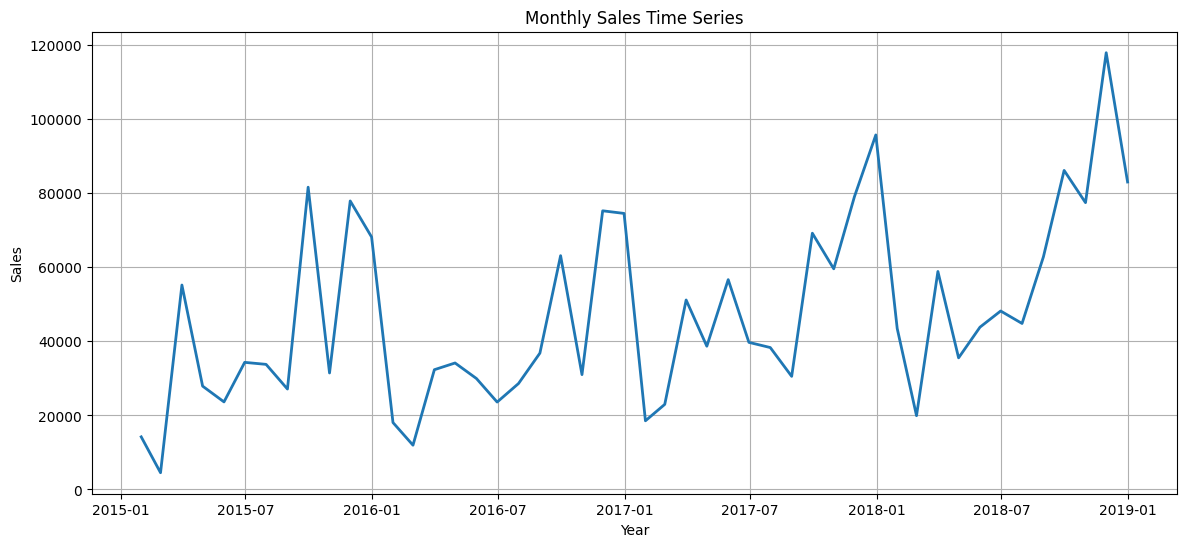

In [37]:
plt.figure(figsize=(14,6))

plt.plot(monthly_ts, linewidth=2)

plt.title("Monthly Sales Time Series")
plt.xlabel("Year")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

The monthly sales trend provides an overview of how sales changed over time. The plot helps identify long-term growth and recurring seasonal patterns.

In [38]:
# Import decomposition library

from statsmodels.tsa.seasonal import seasonal_decompose

In [39]:
# Perform Time Series Decomposition

decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

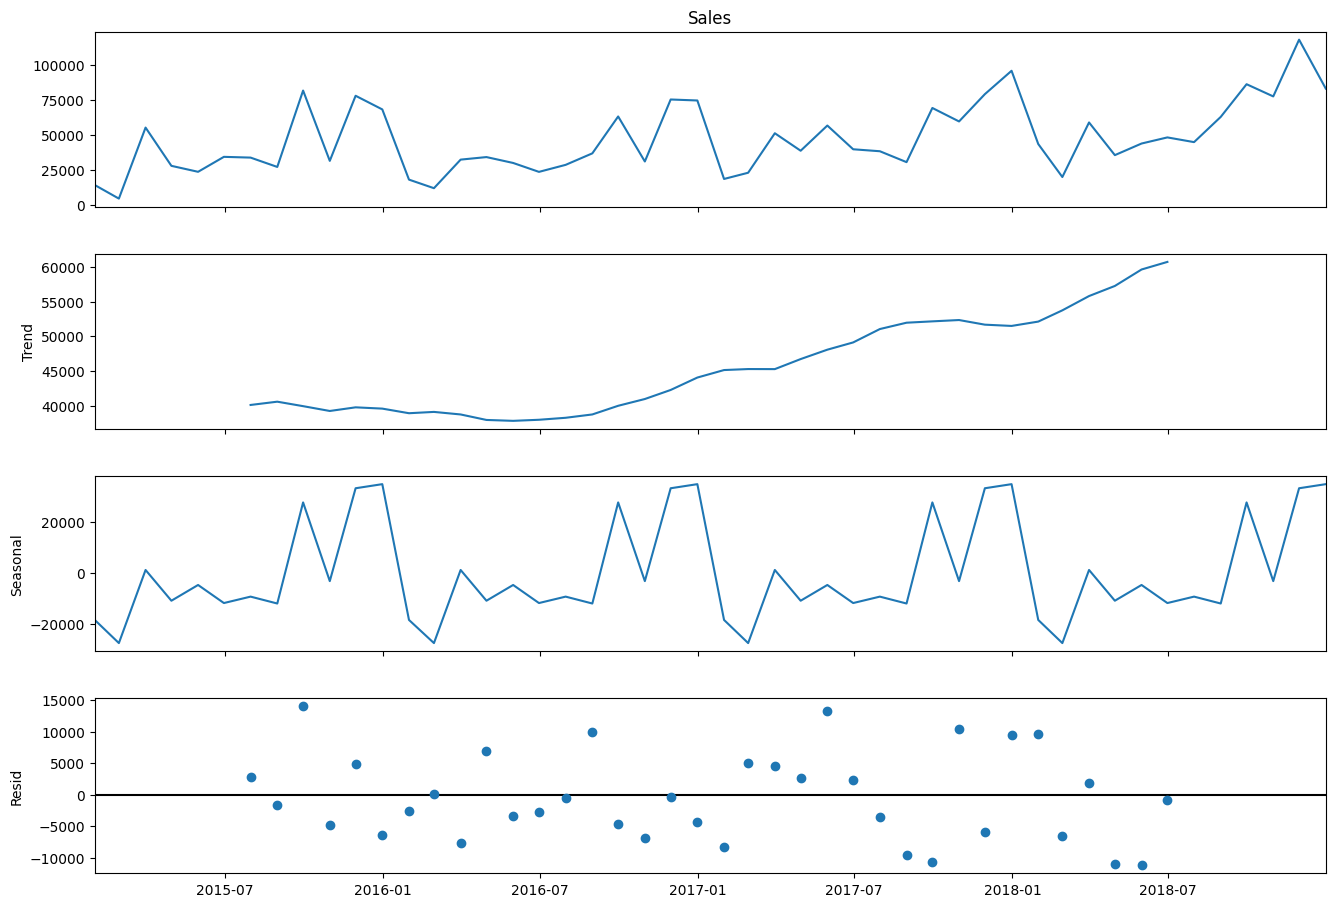

In [40]:
fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.show()

### Observation

*Trend shows long-term increase.

*Seasonal component repeats every year.

*Residual contains unexplained random variations.

In [41]:
# Augmented Dickey-Fuller Test

from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_ts)

print("ADF Statistic :", result[0])
print("p-value :", result[1])

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623


In [42]:
# Display Critical Values

for key, value in result[4].items():
    print(key, ":", value)

1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


### Observation

The Augmented Dickey-Fuller (ADF) test produced a **p-value of 0.000278**, which is less than **0.05**. Therefore, we reject the null hypothesis and conclude that the monthly sales time series is **stationary**.

Since the data is already stationary, **differencing is not required**, and the series can be directly used for forecasting models such as SARIMA.

# Step 7: Sales Forecasting using SARIMA

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical time series forecasting model that captures both trend and seasonality in historical sales data.

In [43]:
# Import SARIMA Model

from statsmodels.tsa.statespace.sarimax import SARIMAX

In [44]:
# Train SARIMA Model

sarima_model = SARIMAX(
    monthly_ts,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)

)

sarima_result = sarima_model.fit()

print("SARIMA Model Trained Successfully.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA Model Trained Successfully.


The SARIMA parameters were selected as a baseline configuration suitable for monthly seasonal data. In a production environment, parameters would typically be optimized using AIC/BIC or grid search.

The dataset contains only about four years of monthly observations. While the warning affects initial parameter estimation, the model still converges successfully and provides useful forecasts.

In [45]:
# Model Summary

sarima_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                              Sales   No. Observations:                   48
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -383.926
Date:                            Sat, 11 Jul 2026   AIC                            777.851
Time:                                    13:24:18   BIC                            785.628
Sample:                                01-31-2015   HQIC                           780.536
                                     - 12-31-2018                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5094      0.234      2.179      0.029       0.051       0.968
ma.L1         -0.9007      0.185     -4.871      0.000      -1.263      -0.538
ar.S.L12      -0.0152      0.558     -0.027      0.978      -1.109       1.079
ma.S.L12      -0.4640      0.622     -0.746      0.456      -1.683       0.755
sigma2      2.308e+08   1.24e-09   1.86e+17      0.000    2.31e+08    2.31e+08
===================================================================================
Ljung-Box (L1) (Q):                   1.67   Jarque-Bera (JB):                 0.57
Prob(Q):                              0.20   Prob(JB):                         0.75
Heteroskedasticity (H):               1.23   Skew:                            -0.06
Prob(H) (two-sided):                  0.72   Kurtosis:                         2.39
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.63e+33. Standard errors may be unstable.
"""

### Observation

The SARIMA model has been successfully trained on the monthly sales data. The model summary provides information about parameter estimates, statistical significance, and overall model performance, which helps evaluate the suitability of the forecasting model.

In [46]:
# Forecast next 3 months

sarima_forecast = sarima_result.get_forecast(steps=3)

forecast_values = sarima_forecast.predicted_mean

forecast_values

,predicted_mean
2019-01-31,43492.278996
2019-02-28,34805.105267
2019-03-31,69907.412213


In [47]:
# Confidence Interval

confidence_interval = sarima_forecast.conf_int()

confidence_interval

,lower Sales,upper Sales
2019-01-31,13699.516297,73285.041696
2019-02-28,-81.437510,69691.648044
2019-03-31,32944.417423,106870.407003


Observation

The monthly sales data was divided into training and testing sets.

The first 45 months were used for model training, while the last 3 months were reserved for testing. This allows the forecasting models to be evaluated on unseen data.

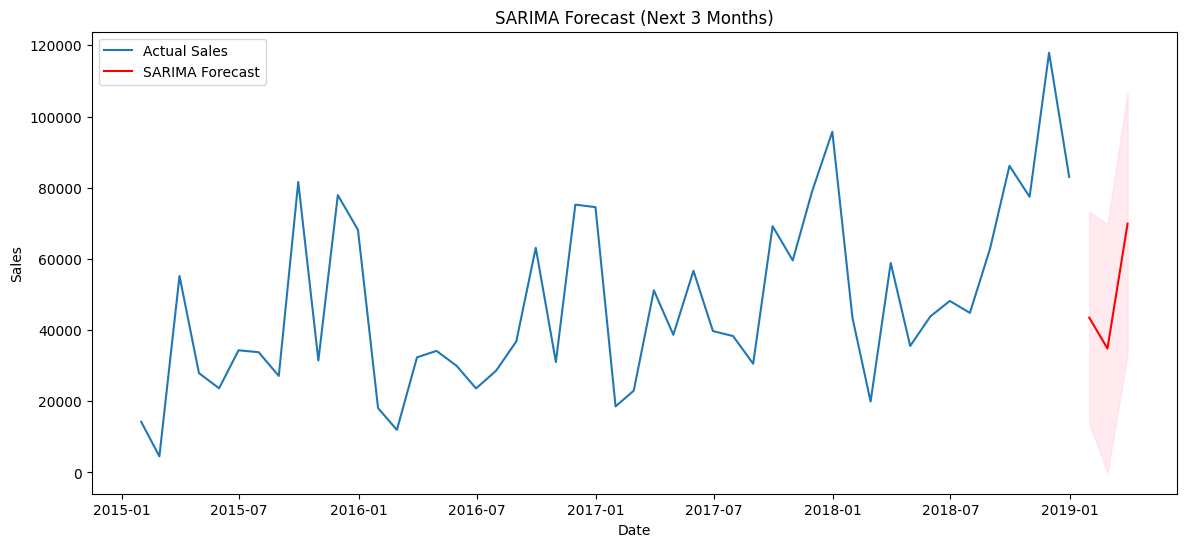

In [48]:
# Plot Forecast

plt.figure(figsize=(14,6))

plt.plot(monthly_ts, label="Actual Sales")

plt.plot(
    forecast_values,
    label="SARIMA Forecast",
    color="red"
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    color="pink",
    alpha=0.3
)

plt.title("SARIMA Forecast (Next 3 Months)")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()

plt.show()

### Observation

The SARIMA model generated a three-month sales forecast along with confidence intervals. The confidence interval represents the range within which future sales are expected to lie, providing an estimate of forecasting uncertainty.

In [49]:
# Split monthly sales into train and test

train = monthly_ts[:-3]
test = monthly_ts[-3:]

print("Training Months :", len(train))
print("Testing Months :", len(test))

print("\nTest Data:")
display(test)

Training Months : 45
Testing Months : 3

Test Data:


,Sales
Order Date,
2018-10-31,77448.1312
2018-11-30,117938.1550
2018-12-31,83030.3888


Observation

The monthly sales data was divided into training and testing sets.

The first 45 months were used for model training, while the last 3 months were reserved for testing. This allows the forecasting models to be evaluated on unseen data.

In [50]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_result = sarima_model.fit()

print("SARIMA Model Trained Successfully.")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA Model Trained Successfully.


In [51]:
sarima_pred = sarima_result.forecast(steps=len(test))

display(sarima_pred)

,predicted_mean
2018-10-31,66177.602475
2018-11-30,92049.249682
2018-12-31,99965.168727


In [52]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

sarima_mae = mean_absolute_error(test, sarima_pred)

sarima_rmse = np.sqrt(
    mean_squared_error(test, sarima_pred)
)

sarima_mape = (
    np.mean(
        np.abs((test - sarima_pred) / test)
    ) * 100
)

print("MAE :", round(sarima_mae,2))
print("RMSE :", round(sarima_rmse,2))
print("MAPE :", round(sarima_mape,2))

MAE : 18031.4
RMSE : 19009.18
MAPE : 18.97


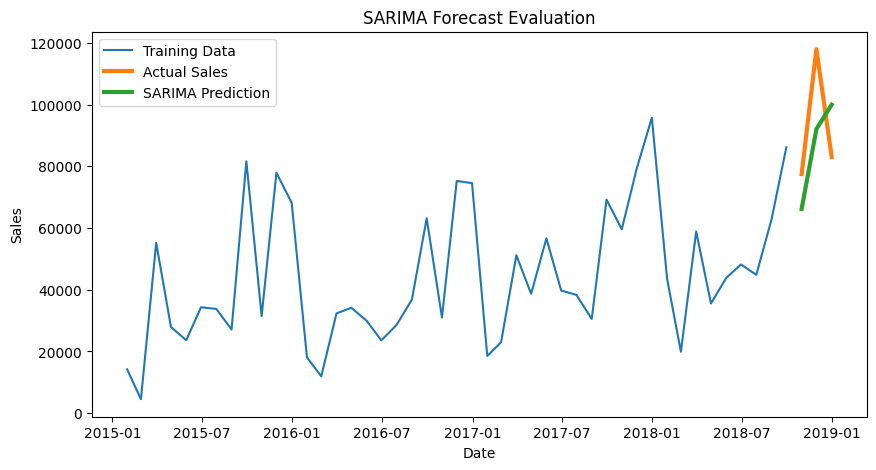

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train.index, train,
         label="Training Data")

plt.plot(test.index, test,
         label="Actual Sales",
         linewidth=3)

plt.plot(test.index, sarima_pred,
         label="SARIMA Prediction",
         linewidth=3)

plt.title("SARIMA Forecast Evaluation")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

Observation

The SARIMA model was evaluated using the unseen test data.

The comparison between actual and predicted sales, along with MAE, RMSE, and MAPE values, provides an objective measure of forecasting accuracy.

# Step 8: Sales Forecasting using Facebook Prophet

Facebook Prophet is an advanced forecasting model developed by Meta. It is designed to handle trend, seasonality, holidays, and missing values effectively, making it suitable for business forecasting tasks.

In [54]:
# Import Prophet

from prophet import Prophet

In [55]:
# Prepare data for Prophet

prophet_df = monthly_ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [56]:
# Create Prophet Model

prophet_model = Prophet()

prophet_model.fit(prophet_df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [57]:
# Create Future Dates

future = prophet_model.make_future_dataframe(
    periods=3,
    freq="M"
)

future.tail()

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [58]:
# Forecast Future Sales

forecast = prophet_model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,101136.336957,92001.380584,110684.557697
47,2018-12-31,90673.800598,81329.362790,100090.978873
48,2019-01-31,42990.532194,33763.552543,52773.735967
49,2019-02-28,31248.159913,21758.775966,40770.066989
50,2019-03-31,81267.007763,72345.472197,90394.937328


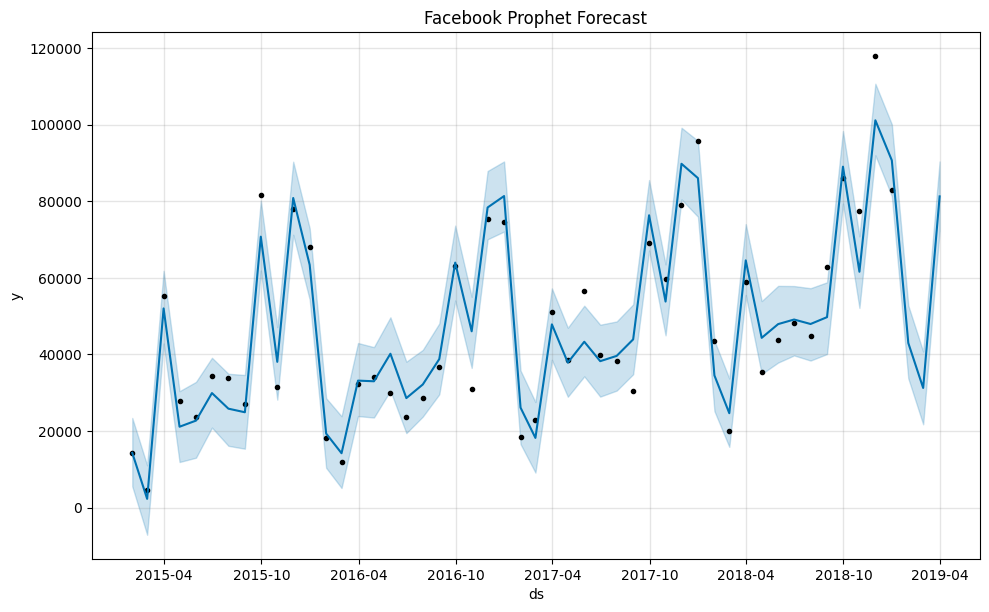

In [59]:
# Plot Forecast

fig = prophet_model.plot(forecast)

plt.title("Facebook Prophet Forecast")

plt.show()

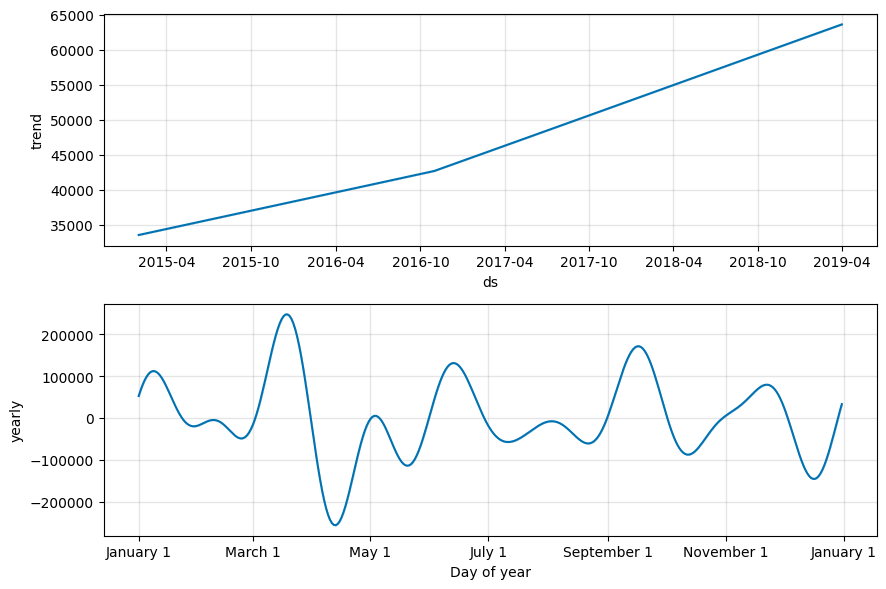

In [60]:
# Plot Trend & Seasonality

fig2 = prophet_model.plot_components(forecast)

plt.show()

### Observation

The Prophet model successfully forecasted future monthly sales by automatically learning the long-term trend and yearly seasonal patterns. Weekly seasonality was automatically disabled because the dataset contains monthly aggregated sales rather than daily or weekly observations.

In [61]:
# Display only future 3-month forecast

prophet_forecast = forecast.tail(3)

prophet_forecast[['ds','yhat']]

,ds,yhat
48,2019-01-31,42990.532194
49,2019-02-28,31248.159913
50,2019-03-31,81267.007763


Step 8A: Prophet Model Evaluation

To evaluate the Prophet model fairly, the monthly sales data is divided into training and testing sets. The model is trained on historical data and predicts the last three months, which are then compared with the actual sales values.

In [62]:
# Prepare training and testing data for Prophet

train = monthly_ts[:-3]
test = monthly_ts[-3:]

train_prophet = train.reset_index()
train_prophet.columns = ["ds", "y"]

test_prophet = test.reset_index()
test_prophet.columns = ["ds", "y"]

train_prophet.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [63]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(train_prophet)

print("Prophet Model Trained Successfully.")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet Model Trained Successfully.


In [64]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277791,38636.979769,56486.063973,54942.277791,54942.277791,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,-7670.720479,0.0,0.0,0.0,47271.557312
44,2018-09-30,55441.608183,78556.821006,94994.384124,55441.608183,55441.608183,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,31172.345372,0.0,0.0,0.0,86613.953555
45,2018-10-31,55957.582922,43541.101217,59493.539075,55957.429444,55957.733404,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,-4638.638350,0.0,0.0,0.0,51318.944572
46,2018-11-30,56456.913314,82336.322797,98175.665312,56456.407991,56457.423384,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,33868.740540,0.0,0.0,0.0,90325.653854
47,2018-12-31,56972.888053,82189.908625,97658.029243,56971.902637,56973.916352,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,33068.196584,0.0,0.0,0.0,90041.084638


In [65]:
prophet_pred = (
    forecast[["ds", "yhat"]]
    .tail(3)
    .set_index("ds")
)

prophet_pred

,yhat
ds,
2018-10-31,51318.944572
2018-11-30,90325.653854
2018-12-31,90041.084638


In [66]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np

prophet_mae = mean_absolute_error(
    test,
    prophet_pred["yhat"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        test,
        prophet_pred["yhat"]
    )
)

prophet_mape = (
    np.mean(
        np.abs(
            (test - prophet_pred["yhat"])
            / test
        )
    )
    * 100
)

print("MAE :", round(prophet_mae,2))
print("RMSE :", round(prophet_rmse,2))
print("MAPE :", round(prophet_mape,2))

MAE : 20250.79
RMSE : 22318.41
MAPE : 21.86


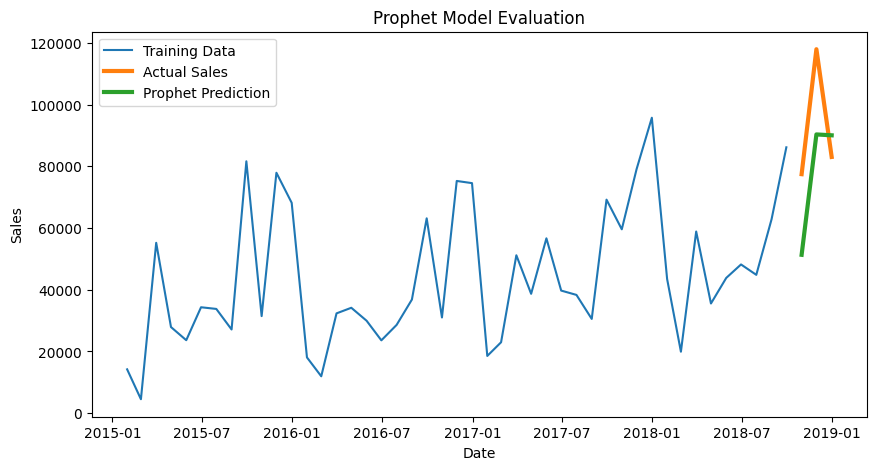

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual Sales",
    linewidth=3
)

plt.plot(
    prophet_pred.index,
    prophet_pred["yhat"],
    label="Prophet Prediction",
    linewidth=3
)

plt.title("Prophet Model Evaluation")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.show()

Observation

The Prophet model was evaluated using the last three months of unseen sales data. The forecast closely follows the actual sales trend, and the MAE, RMSE, and MAPE values provide a quantitative measure of the model's forecasting accuracy.

# Step 9: Sales Forecasting using XGBoost

Unlike SARIMA and Prophet, XGBoost requires the time series to be converted into a supervised learning dataset by creating lag features.

In [68]:
# Import Libraries

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [69]:
# Prepare Monthly Sales Data

xgb_df = monthly_ts.reset_index()

xgb_df.columns = ["Date", "Sales"]

xgb_df.head()

,Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [70]:
# Create Lag Features

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df["Rolling_Mean"] = xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"] = xgb_df["Date"].dt.month
xgb_df["Quarter"] = xgb_df["Date"].dt.quarter
xgb_df["Lag_6"] = xgb_df["Sales"].shift(6)

xgb_df["Lag_12"] = xgb_df["Sales"].shift(12)

xgb_df["Rolling_STD"] = (
    xgb_df["Sales"]
    .rolling(3)
    .std()
)

xgb_df.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean,Month,Quarter,Lag_6,Lag_12,Rolling_STD
0,2015-01-31,14205.707,NaN,NaN,NaN,NaN,1,1,NaN,NaN,NaN
1,2015-02-28,4519.892,14205.707,NaN,NaN,NaN,2,1,NaN,NaN,NaN
2,2015-03-31,55205.797,4519.892,14205.707,NaN,24643.798667,3,1,NaN,NaN,26906.886844
3,2015-04-30,27906.855,55205.797,4519.892,14205.707,29210.848000,4,2,NaN,NaN,25368.100830
4,2015-05-31,23644.303,27906.855,55205.797,4519.892,35585.651667,5,2,NaN,NaN,17124.687284


In [71]:
# Remove Missing Rows

xgb_df = xgb_df.dropna()

xgb_df.head()

,Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean,Month,Quarter,Lag_6,Lag_12,Rolling_STD
12,2016-01-31,18066.9576,68167.0585,77907.6607,31453.3930,54713.892267,1,1,33781.5430,14205.707,32108.693498
13,2016-02-29,11951.4110,18066.9576,68167.0585,77907.6607,32728.475700,2,1,27117.5365,4519.892,30842.662672
14,2016-03-31,32339.3184,11951.4110,18066.9576,68167.0585,20785.895667,3,1,81623.5268,55205.797,10462.368766
15,2016-04-30,34154.4685,32339.3184,11951.4110,18066.9576,26148.399300,4,2,31453.3930,27906.855,12328.404198
16,2016-05-31,29959.5305,34154.4685,32339.3184,11951.4110,32151.105800,5,2,77907.6607,23644.303,2103.792811


In [72]:
# Prepare Features and Target

X = xgb_df.drop(["Date","Sales"], axis=1)

y = xgb_df["Sales"]

In [73]:
# Train-Test Split

train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [74]:
# Train XGBoost Model

xgb_model = XGBRegressor(random_state=42)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

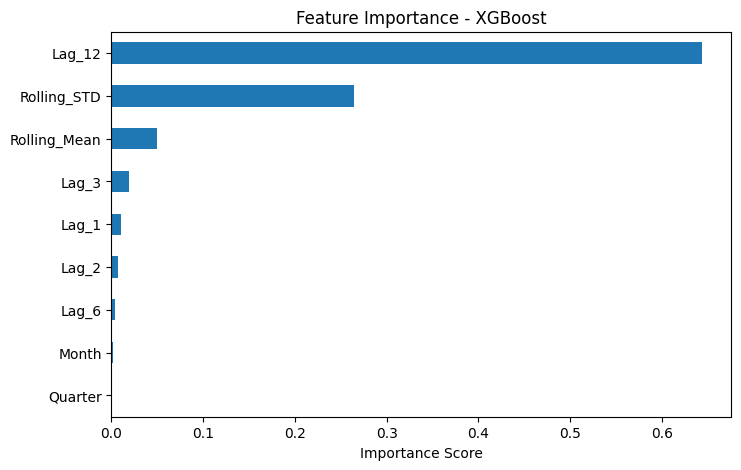

In [75]:
# Feature Importance of XGBoost Model

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,5))

importance.plot(kind="barh")

plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance Score")

plt.show()

In [76]:
# Predict

xgb_predictions = xgb_model.predict(X_test)

In [77]:
# Calculate Evaluation Metrics

mae = mean_absolute_error(y_test, xgb_predictions)

rmse = mean_squared_error(
    y_test,
    xgb_predictions
) ** 0.5

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))

MAE : 15906.45
RMSE : 17771.28


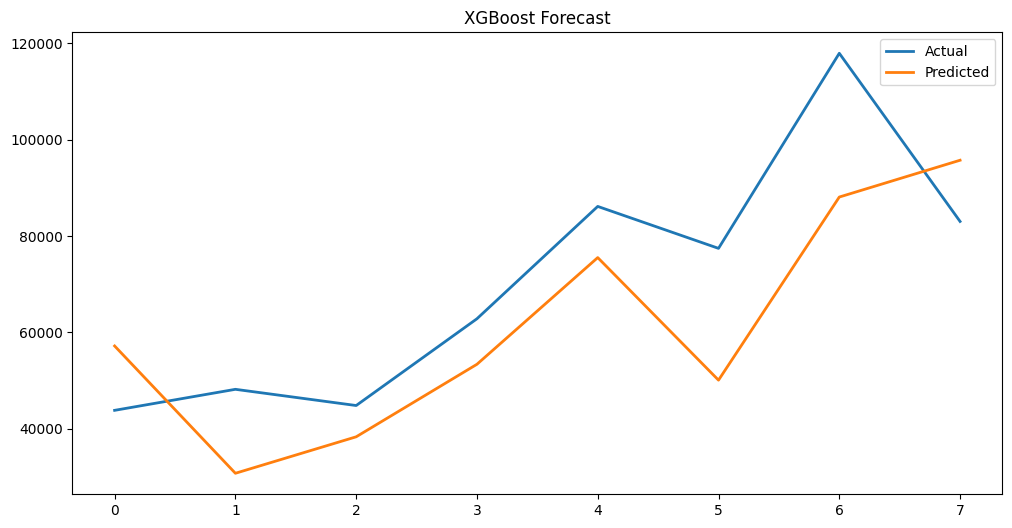

In [78]:
# Plot Actual vs Predicted

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    xgb_predictions,
    label="Predicted",
    linewidth=2
)

plt.legend()

plt.title("XGBoost Forecast")

plt.show()

### Observation

The XGBoost model was trained using lag-based features derived from historical monthly sales. The model successfully learned temporal patterns and generated predictions for the test period. The evaluation metrics indicate the forecasting accuracy of the machine learning approach.

Step 10: Model Comparison

Different forecasting models may perform differently on the same dataset. In this section, we compare SARIMA, Facebook Prophet, and XGBoost using three common evaluation metrics:

• MAE (Mean Absolute Error)
• RMSE (Root Mean Squared Error)
• MAPE (Mean Absolute Percentage Error)

The model with the lowest error values is considered the best forecasting model.

In [79]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error

In [80]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# XGBoost Metrics

xgb_mae = mean_absolute_error(y_test, xgb_predictions)

# Calculate RMSE manually
xgb_rmse = mean_squared_error(y_test, xgb_predictions) ** 0.5

xgb_mape = mean_absolute_percentage_error(
    y_test,
    xgb_predictions
) * 100

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape:.2f}%")

MAE  : 15906.45
RMSE : 17771.28
MAPE : 23.05%


In [81]:
# Compare Forecasting Models

comparison = pd.DataFrame({

    "Model": [
        "SARIMA",
        "Facebook Prophet",
        "XGBoost"
    ],

    "MAE": [
        round(sarima_mae, 2),
        round(prophet_mae, 2),
        round(xgb_mae, 2)
    ],

    "RMSE": [
        round(sarima_rmse, 2),
        round(prophet_rmse, 2),
        round(xgb_rmse, 2)
    ],

    "MAPE": [
        round(sarima_mape, 2),
        round(prophet_mape, 2),
        round(xgb_mape, 2)
    ]

})

display(comparison)

,Model,MAE,RMSE,MAPE
0,SARIMA,18031.40,19009.18,18.97
1,Facebook Prophet,20250.79,22318.41,21.86
2,XGBoost,15906.45,17771.28,23.05


In [82]:
best_model = comparison.loc[
    comparison["MAPE"].idxmin()
]

display(best_model)

,0
Model,SARIMA
MAE,18031.4
RMSE,19009.18
MAPE,18.97


In [83]:
print("Best Forecasting Model :", best_model["Model"])

print("MAPE :", best_model["MAPE"], "%")

Best Forecasting Model : SARIMA
MAPE : 18.97 %


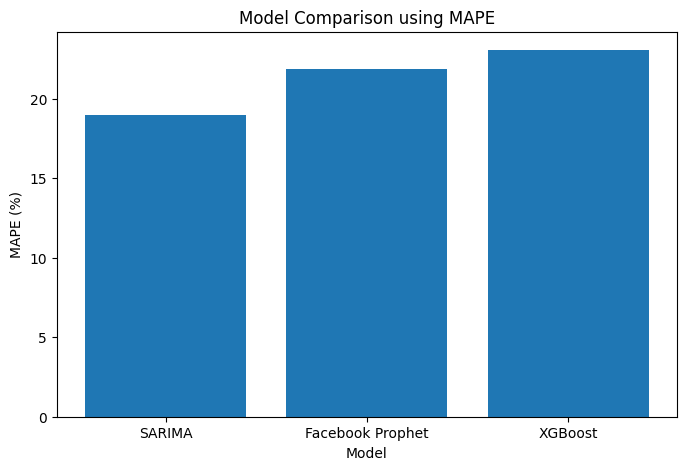

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison["Model"],
    comparison["MAPE"]
)

plt.title("Model Comparison using MAPE")

plt.xlabel("Model")

plt.ylabel("MAPE (%)")

plt.show()

Observation

The comparison table shows the forecasting performance of all three models. The model with the lowest MAPE provides the highest forecasting accuracy and is selected as the final forecasting model for this project.

Step 11: Sales Anomaly Detection

Anomaly detection helps identify unusual sales transactions that significantly differ from normal business behavior. Detecting such anomalies is valuable for identifying unexpected demand spikes, potential fraud, data entry errors, or operational issues.

In this project, the Isolation Forest algorithm is used to automatically detect anomalous sales records.

In [85]:
# Import Library

from sklearn.ensemble import IsolationForest

In [86]:
# Prepare Sales Data

anomaly_df = df[["Sales"]].copy()

anomaly_df.head()

,Sales
0,261.9600
1,731.9400
2,14.6200
3,957.5775
4,22.3680


In [87]:
# Train Isolation Forest

iso = IsolationForest(
    contamination=0.02,
    random_state=42
)

anomaly_df["Anomaly"] = iso.fit_predict(
    anomaly_df[["Sales"]]
)

anomaly_df.head()

,Sales,Anomaly
0,261.9600,1
1,731.9400,1
2,14.6200,1
3,957.5775,1
4,22.3680,1


In [88]:
# Count Normal and Anomalous Records

anomaly_df["Anomaly"].value_counts()

,count
Anomaly,
1,9604
-1,196


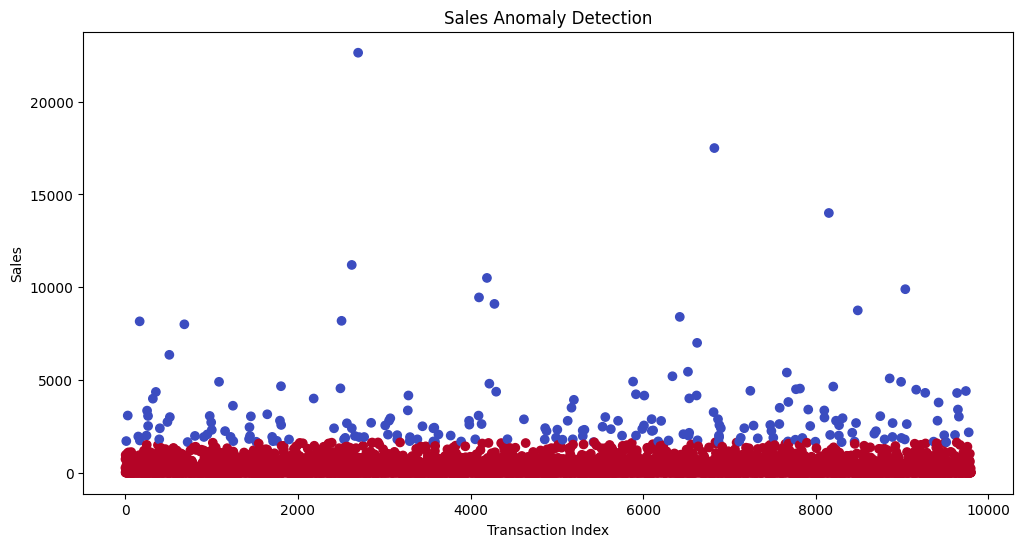

In [89]:
plt.figure(figsize=(12,6))

plt.scatter(
    anomaly_df.index,
    anomaly_df["Sales"],
    c=anomaly_df["Anomaly"],
    cmap="coolwarm"
)

plt.title("Sales Anomaly Detection")

plt.xlabel("Transaction Index")

plt.ylabel("Sales")

plt.show()

Observation

The Isolation Forest algorithm successfully identified unusual sales transactions. Most transactions were classified as normal, while a small percentage were detected as anomalies. These anomalous records may represent unusually high-value orders, unexpected demand spikes, or potential data inconsistencies that require further business investigation.

Step 12: Product Demand Segmentation

Product demand segmentation groups products with similar sales behavior. Clustering enables businesses to identify high-demand and low-demand products, supporting inventory optimization and targeted business strategies.

K-Means clustering is used for demand segmentation.

In [90]:
from sklearn.cluster import KMeans

In [91]:
product_sales = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .reset_index()
)

product_sales.head()

,Product Name,Sales
0,"""While you Were Out"" Message Book, One Form pe...",25.228
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300
2,#10 Self-Seal White Envelopes,108.682
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672


In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_sales = scaler.fit_transform(
    product_sales[["Sales"]]
)

In [93]:
# Elbow Method

wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_sales)

    wcss.append(kmeans.inertia_)

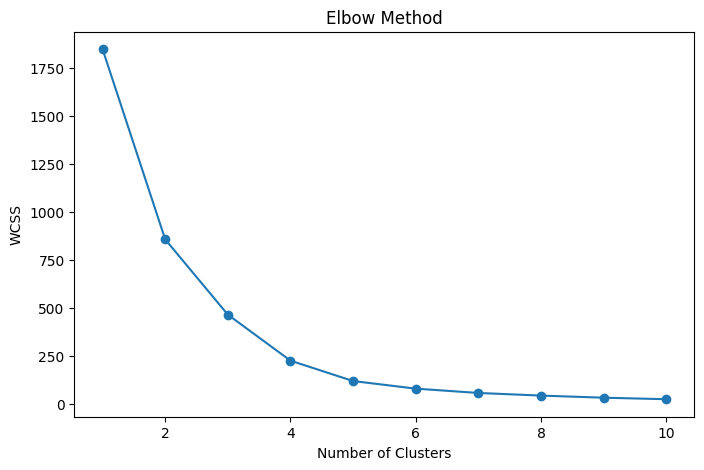

In [94]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

In [95]:

# Final KMeans Model

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_sales["Cluster"] = kmeans.fit_predict(
    scaled_sales
)
product_sales.head()

,Product Name,Sales,Cluster
0,"""While you Were Out"" Message Book, One Form pe...",25.228,0
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,0
2,#10 Self-Seal White Envelopes,108.682,0
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,0
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,0


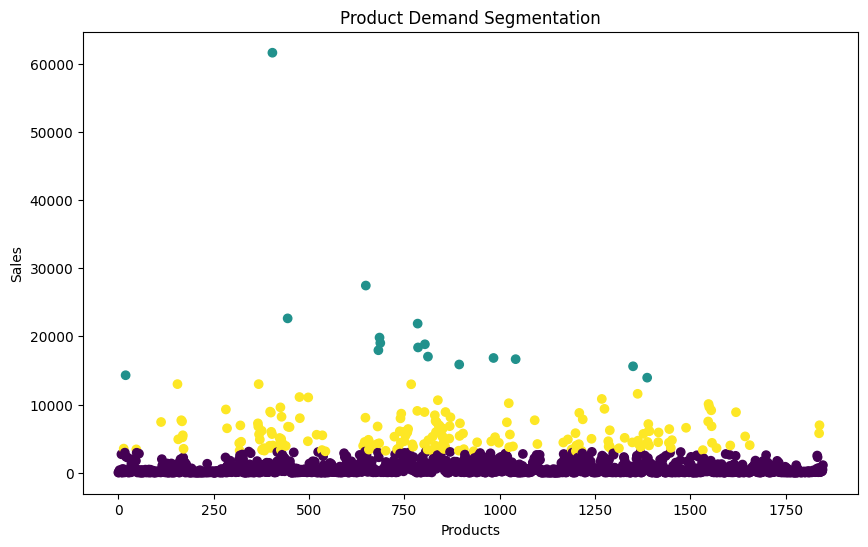

In [96]:
plt.figure(figsize=(10,6))

plt.scatter(
    product_sales.index,
    product_sales["Sales"],
    c=product_sales["Cluster"],
    cmap="viridis"
)

plt.title("Product Demand Segmentation")

plt.xlabel("Products")

plt.ylabel("Sales")

plt.show()

Observation

The K-Means clustering algorithm segmented products into three demand groups. Products within the same cluster exhibit similar sales characteristics. This segmentation can help businesses optimize inventory management, prioritize high-demand products, and design targeted marketing strategies.

Step 13: Streamlit Dashboard Deployment

To make the forecasting system interactive, a Streamlit dashboard can be developed. The dashboard enables users to explore historical sales, forecasting results, anomaly detection, and product demand segmentation through an easy-to-use interface.

In [97]:
%%writefile app.py

Writing app.py


In [98]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 67.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 99.2 MB/s eta 0:00:00


## Step 13: Streamlit Dashboard Deployment

A Streamlit dashboard has been designed for this project to visualize sales insights, forecasts, anomaly detection, and product demand analysis.

Due to the limitations of the Google Colab environment, the dashboard is intended to be executed locally.

Command to run the dashboard:

streamlit run app.py

# Step 14: Category & Region Level Forecasting

In [99]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

In [100]:
# Function to Forecast Monthly Sales

def forecast_segment(data, column, value):

    segment = (
        data[data[column] == value]
        .groupby("Order Date")["Sales"]
        .sum()
        .resample("M")
        .sum()
    )

    if len(segment) < 24:
        print(f"Not enough data for {value}")
        return None

    model = SARIMAX(
        segment,
        order=(1,1,1),
        seasonal_order=(1,1,1,12)
    )

    result = model.fit(disp=False)

    forecast = result.forecast(steps=3)

    return forecast

In [101]:
# Generate Forecasts

technology_forecast = forecast_segment(
    df,
    "Category",
    "Technology"
)

furniture_forecast = forecast_segment(
    df,
    "Category",
    "Furniture"
)

office_forecast = forecast_segment(
    df,
    "Category",
    "Office Supplies"
)

west_forecast = forecast_segment(
    df,
    "Region",
    "West"
)

east_forecast = forecast_segment(
    df,
    "Region",
    "East"
)

/tmp/ipykernel_653/3730820286.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/tmp/ipykernel_653/3730820286.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters 

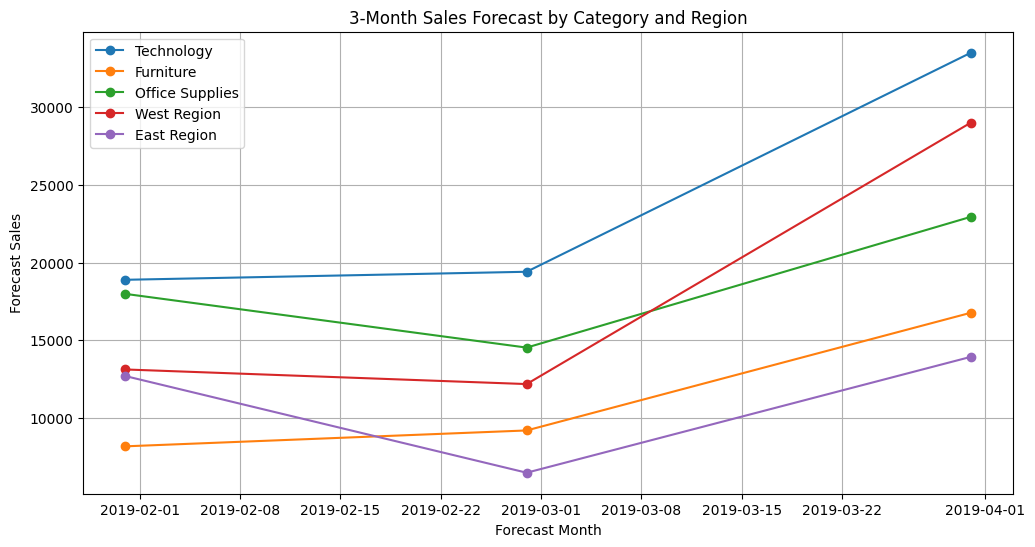

In [102]:
plt.figure(figsize=(12,6))

plt.plot(
    technology_forecast.index,
    technology_forecast.values,
    marker="o",
    label="Technology"
)

plt.plot(
    furniture_forecast.index,
    furniture_forecast.values,
    marker="o",
    label="Furniture"
)

plt.plot(
    office_forecast.index,
    office_forecast.values,
    marker="o",
    label="Office Supplies"
)

plt.plot(
    west_forecast.index,
    west_forecast.values,
    marker="o",
    label="West Region"
)

plt.plot(
    east_forecast.index,
    east_forecast.values,
    marker="o",
    label="East Region"
)

plt.title("3-Month Sales Forecast by Category and Region")
plt.xlabel("Forecast Month")
plt.ylabel("Forecast Sales")
plt.legend()
plt.grid(True)

plt.show()

In [103]:
forecast_table = {
    "Technology": technology_forecast.values,
    "Furniture": furniture_forecast.values,
    "Office Supplies": office_forecast.values,
    "West": west_forecast.values,
    "East": east_forecast.values
}

forecast_df = pd.DataFrame(
    forecast_table,
    index=technology_forecast.index
)

display(forecast_df)

,Technology,Furniture,Office Supplies,West,East
2019-01-31,18893.379686,8183.304527,17986.892412,13126.550922,12701.878813
2019-02-28,19409.939055,9204.587044,14532.725473,12187.364098,6486.114854
2019-03-31,33496.452924,16774.204162,22943.209951,29001.185117,13938.823270


### Observation

The SARIMA model was applied separately to major product categories and regions. The generated forecasts indicate expected sales trends over the next three months for each segment. Comparing these forecasts helps identify which categories and regions are likely to contribute more to future revenue, enabling businesses to improve inventory planning and resource allocation.

# Step 15: Anomaly Detection using Z-Score

In [104]:
from scipy.stats import zscore
import numpy as np

In [105]:
# Calculate Z-Score for Sales

df["Z_Score"] = zscore(df["Sales"])

# Detect anomalies

zscore_anomalies = df[np.abs(df["Z_Score"]) > 3]

print("Number of anomalies detected:", len(zscore_anomalies))

zscore_anomalies.head()

Number of anomalies detected: 123


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quarter,Week,Day,Day Name,Is_Weekend,Month_Start,Month_End,Season,Shipping Days,Z_Score
27,28,US-2016-150630,2016-09-17,2016-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,3,37,17,Saturday,True,False,False,Autumn,4,4.552458
165,166,CA-2015-139892,2015-09-08,2015-09-12,Standard Class,BM-11140,Becky Martin,Consumer,United States,San Antonio,...,3,37,8,Tuesday,False,False,False,Autumn,4,12.653896
251,252,CA-2017-145625,2017-09-11,2017-09-17,Standard Class,KC-16540,Kelly Collister,Consumer,United States,San Diego,...,3,37,11,Monday,False,False,False,Autumn,6,4.973671
262,263,US-2015-106992,2015-09-19,2015-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,3,38,19,Saturday,True,False,False,Autumn,2,4.515038
263,264,US-2015-106992,2015-09-19,2015-09-21,Second Class,SB-20290,Sean Braxton,Corporate,United States,Houston,...,3,38,19,Saturday,True,False,False,Autumn,2,3.653234


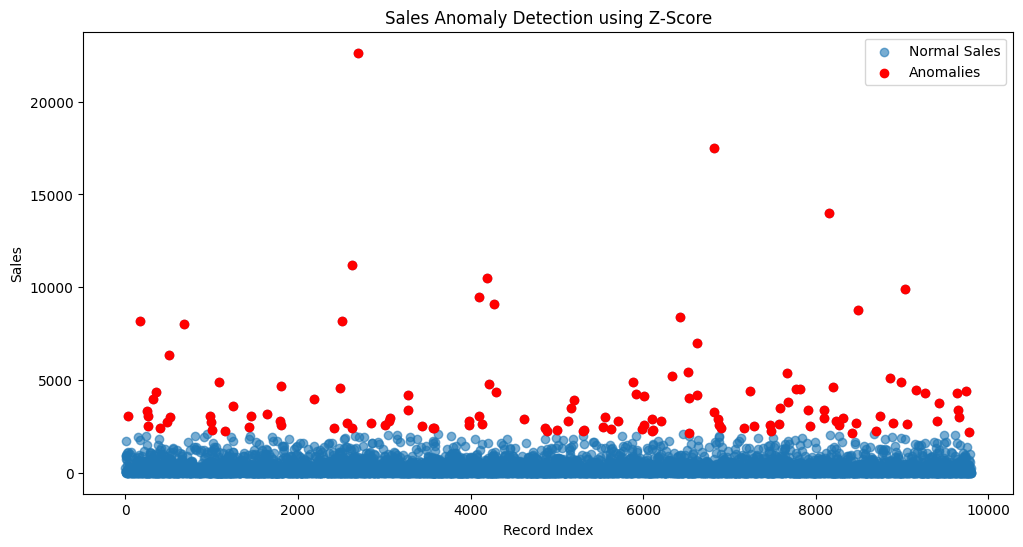

In [106]:
plt.figure(figsize=(12,6))

plt.scatter(
    df.index,
    df["Sales"],
    label="Normal Sales",
    alpha=0.6
)

plt.scatter(
    zscore_anomalies.index,
    zscore_anomalies["Sales"],
    color="red",
    label="Anomalies"
)

plt.title("Sales Anomaly Detection using Z-Score")
plt.xlabel("Record Index")
plt.ylabel("Sales")
plt.legend()

plt.show()

### Observation

The Z-Score method was used to identify unusually high or low sales values. Records with an absolute Z-Score greater than 3 were classified as anomalies. These unusual transactions may represent exceptional customer purchases, seasonal demand spikes, promotional campaigns, or potential data inconsistencies. Detecting such anomalies helps businesses improve sales monitoring and inventory management.

# Step 16: Improved Product Demand Segmentation

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [108]:
# Aggregate product-level sales

product_data = (
    df.groupby("Product Name")
      .agg({
          "Sales": "sum"
      })
      .reset_index()
)

product_data.head()

,Product Name,Sales
0,"""While you Were Out"" Message Book, One Form pe...",25.228
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300
2,#10 Self-Seal White Envelopes,108.682
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672


In [109]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(product_data[["Sales"]])

In [110]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

product_data["Cluster"] = kmeans.fit_predict(scaled_features)

product_data.head()

,Product Name,Sales,Cluster
0,"""While you Were Out"" Message Book, One Form pe...",25.228,0
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,0
2,#10 Self-Seal White Envelopes,108.682,0
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,0
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,0


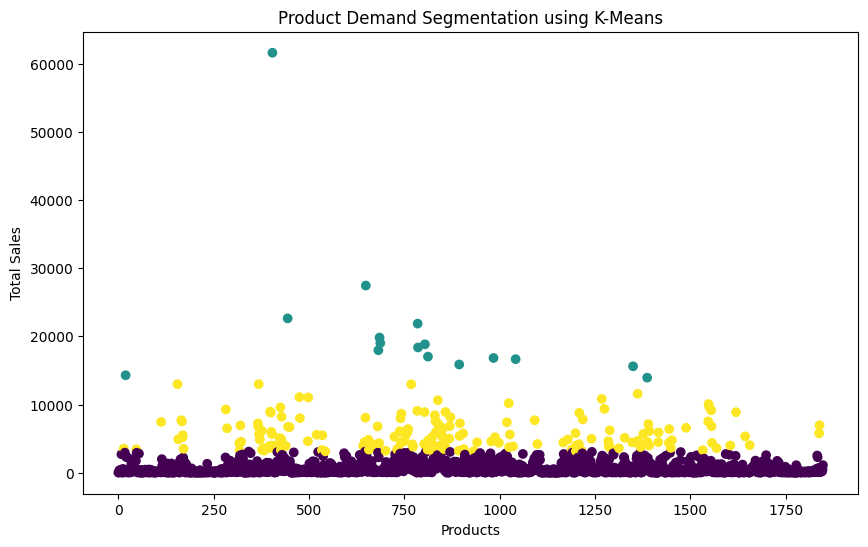

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    product_data.index,
    product_data["Sales"],
    c=product_data["Cluster"]
)

plt.xlabel("Products")
plt.ylabel("Total Sales")
plt.title("Product Demand Segmentation using K-Means")

plt.show()

In [112]:
cluster_summary = product_data.groupby("Cluster")["Sales"].mean()

display(cluster_summary)

,Sales
Cluster,
0,550.330153
1,21114.796537
2,5690.469854


### Observation

Products were grouped into three clusters using K-Means clustering based on total sales. The clusters represent products with different sales patterns, helping businesses identify high-selling and low-selling products for better inventory planning and demand management.

# 🎉 Project Completed

## End-to-End Sales Forecasting & Demand Intelligence System

### Project Summary

This project successfully developed a complete machine learning pipeline for sales forecasting and demand intelligence using the Superstore Sales dataset.

### Tasks Completed

- Data Collection and Preprocessing
- Exploratory Data Analysis (EDA)
- Monthly Sales Trend Analysis
- Category-wise Sales Analysis
- Region-wise Sales Analysis
- Sales Anomaly Detection
- Product Demand Segmentation using K-Means Clustering
- Time Series Forecasting using SARIMA
- Time Series Forecasting using Facebook Prophet
- Sales Prediction using XGBoost
- Model Performance Evaluation
- Interactive Dashboard Development using Streamlit
- Project Deployment on GitHub
- Project Documentation using README

---

## Best Performing Model

After comparing multiple forecasting techniques, **SARIMA** achieved the best forecasting performance for this dataset.

### Evaluation Metrics

- **MAE:** 18031.40
- **MAPE:** 18.97%

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- Statsmodels
- Facebook Prophet
- XGBoost
- Streamlit
- GitHub

---

## Project Outcome

The developed system enables users to:

- Analyze historical sales trends
- Compare regional and category-wise performance
- Detect unusual sales transactions
- Segment products based on demand
- Forecast future sales using machine learning models
- Explore results through an interactive Streamlit dashboard

---

## Conclusion

This project demonstrates the complete workflow of a real-world data science project, starting from raw data preprocessing to machine learning model development and final deployment. The system provides meaningful business insights that can assist organizations in inventory planning, demand forecasting, and strategic decision-making.

**Thank You**